In [1]:
#Import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load CSV dataset
df = pd.read_csv("/content/drive/MyDrive/Simulation and Modeling Lab Project/tip.csv")

# Display first few rows
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


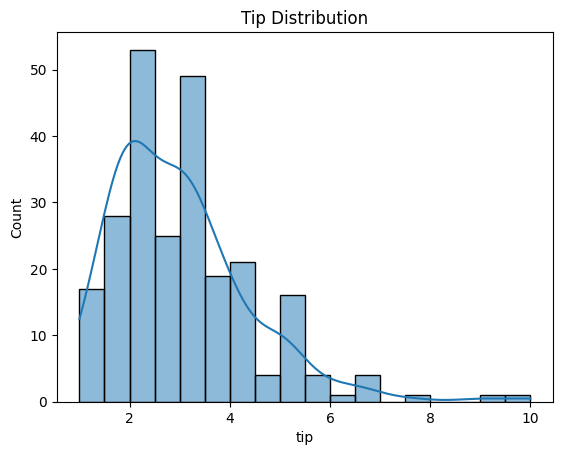

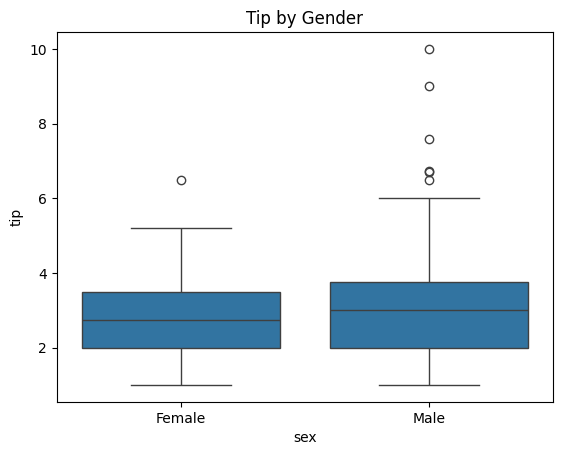

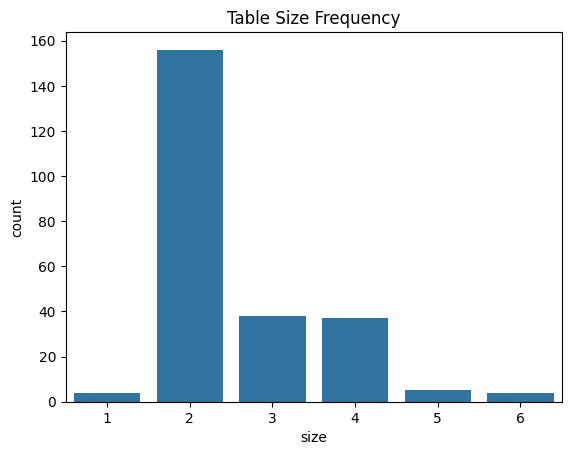

In [4]:
#Explore and visualize the data

df.info()
df.describe()

# Example visualizations
sns.histplot(df['tip'], kde=True)
plt.title('Tip Distribution')
plt.show()

sns.boxplot(x='sex', y='tip', data=df)
plt.title('Tip by Gender')
plt.show()

sns.countplot(x='size', data=df)
plt.title('Table Size Frequency')
plt.show()

In [5]:
# Preprocess data

df['tip_pct'] = df['tip'] / df['total_bill'] * 100
for col in ['sex','smoker','day','time']:
    df[col] = df[col].astype('category')

In [6]:
#One-sample t-test
#Hypothesis: Is the average tip different from $3?

alpha = 0.05

sample = df['tip']
t_stat, p_val = stats.ttest_1samp(sample, 3.0)
print(f"t = {t_stat:.3f},  p = {p_val:.3f}")
if p_val < 0.05:
    print(" Reject H₀: Mean tip ≠ $3")
else:
    print(" Fail to reject H₀: Mean tip ≈ $3")


t = -0.019,  p = 0.985
 Fail to reject H₀: Mean tip ≈ $3


t = 1.490,  p = 0.138


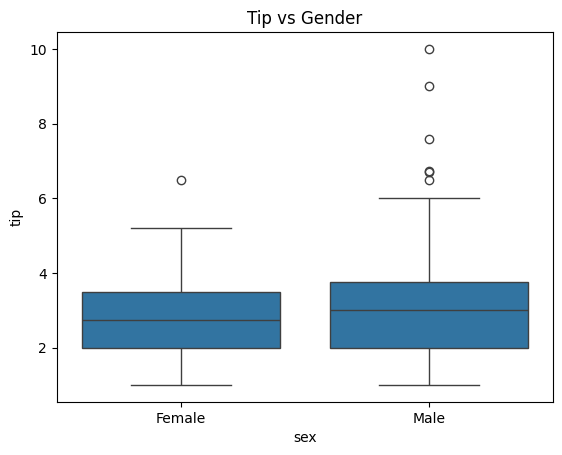

In [7]:
#Two-sample t-test
#Hypothesis: Do male and female customers tip differently?

male = df[df['sex']=='Male']['tip']
female = df[df['sex']=='Female']['tip']
t2, p2 = stats.ttest_ind(male, female, equal_var=False)
print(f"t = {t2:.3f},  p = {p2:.3f}")

sns.boxplot(x='sex', y='tip', data=df)
plt.title('Tip vs Gender')
plt.show()

Chi² = 0.5053733928754354 p = 0.4771485672079724


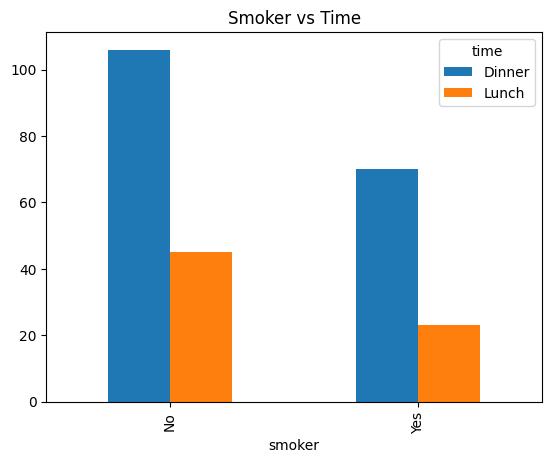

In [8]:
#Chi-square test of independence
#Hypothesis: Is smoking status independent of meal time?

table = pd.crosstab(df['smoker'], df['time'])
chi2, p, dof, exp = stats.chi2_contingency(table)
print('Chi² =', chi2, 'p =', p)
table.plot(kind='bar')
plt.title('Smoker vs Time')
plt.show()

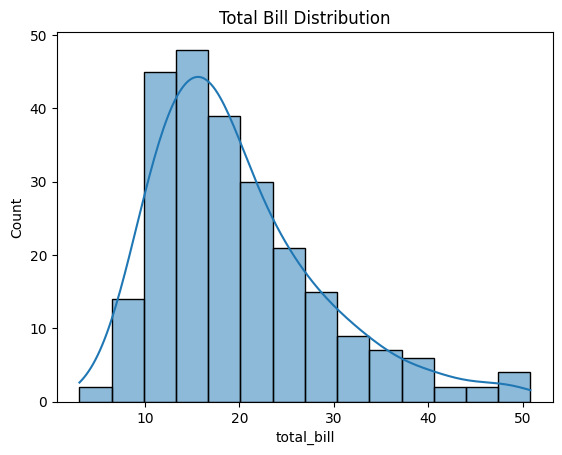

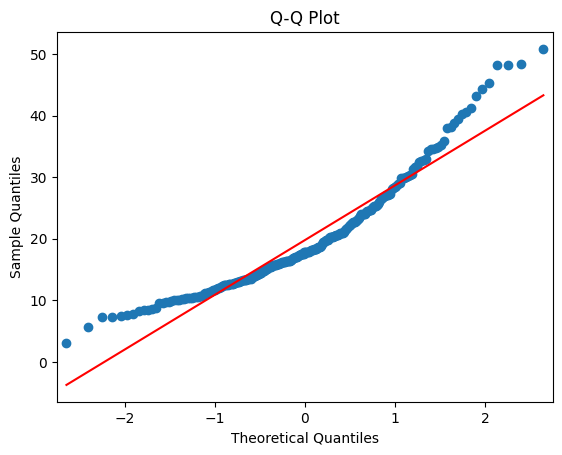

Shapiro-Wilk p = 3.3245391868090786e-10


In [9]:
# Normality test for total_bill

x = df['total_bill']
sns.histplot(x, kde=True)
plt.title('Total Bill Distribution')
plt.show()

sm.qqplot(x, line='s')
plt.title('Q-Q Plot')
plt.show()

sh_p = stats.shapiro(x)[1]
print('Shapiro-Wilk p =', sh_p)

Chi² = 425.0 p = 1.2102825794865112e-89


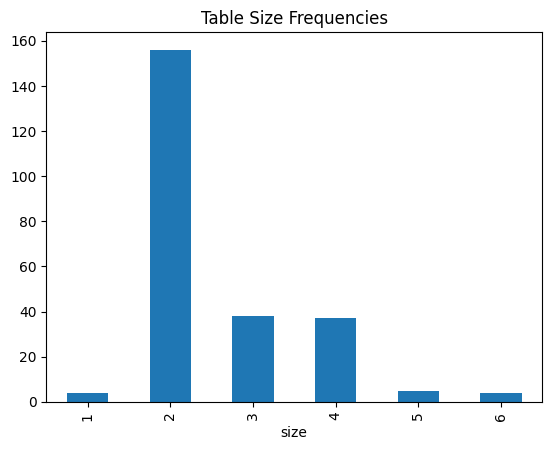

In [10]:
#Uniformity test for table size

obs = df['size'].value_counts().sort_index()
expected = np.ones(len(obs)) * len(df)/len(obs)
chi2, p = stats.chisquare(obs, expected)
print('Chi² =', chi2, 'p =', p)
obs.plot(kind='bar')
plt.title('Table Size Frequencies')
plt.show()

In [11]:
#Simple regression model

model = smf.ols('tip ~ total_bill + C(sex) + C(smoker) + C(time) + size', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     42.00
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           6.57e-31
Time:                        15:54:00   Log-Likelihood:                -347.78
No. Observations:                 244   AIC:                             707.6
Df Residuals:                     238   BIC:                             728.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.7253      0.232  

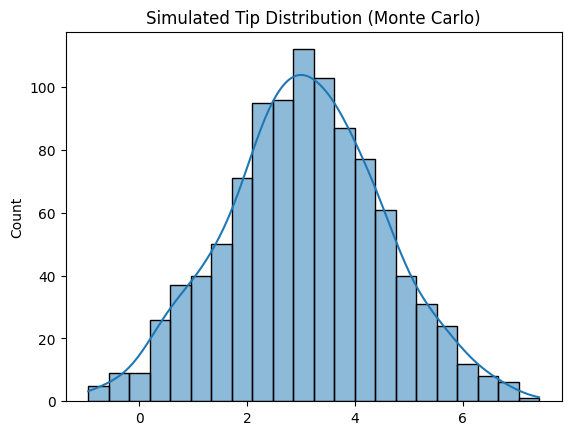

In [12]:
# Random simulation of tips (based on mean & std)

simulated_tips = np.random.normal(df['tip'].mean(), df['tip'].std(), 1000)
sns.histplot(simulated_tips, kde=True)
plt.title('Simulated Tip Distribution (Monte Carlo)')
plt.show()

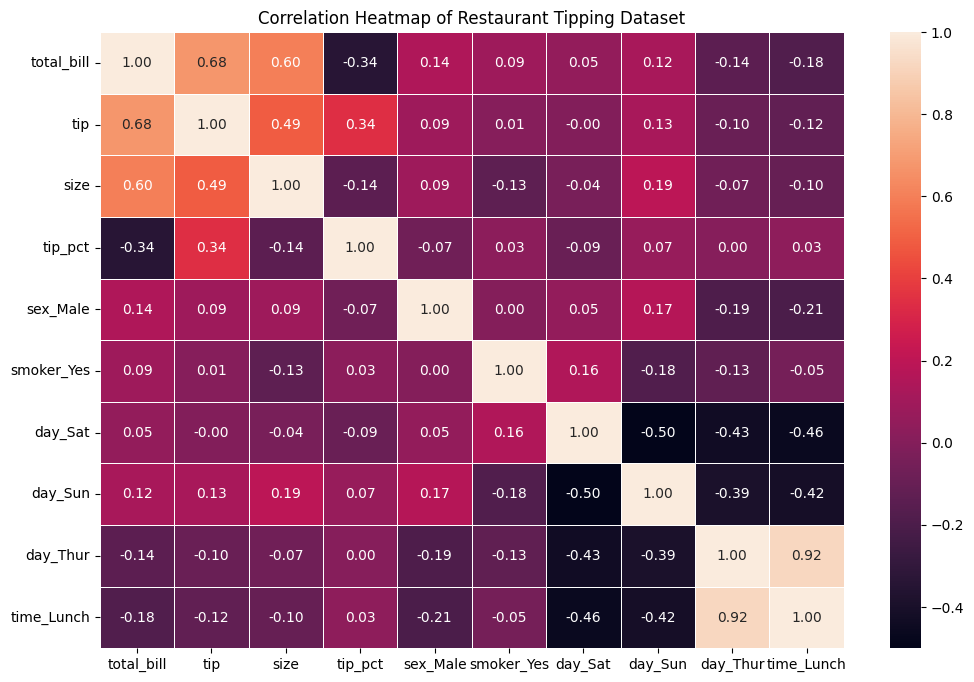

In [13]:
## Correlation Heatmap

# Create a copy to avoid modifying the original data
df_corr = df.copy()

# Convert categorical columns into numeric using one-hot encoding
df_corr = pd.get_dummies(df_corr, drop_first=True)

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Restaurant Tipping Dataset")
plt.show()